# Métricas de Evaluación Básicas

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/01_introduccion/03_metricas_evaluacion_basicas.ipynb)



## Objetivos
- Entender que no existe una única métrica perfecta.
- Aprender las métricas fundamentales para **Regresión** (MAE, MSE, RMSE, R2).
- Aprender las métricas fundamentales para **Clasificación** (Accuracy, Precision, Recall, F1-Score).
- Comprender el peligro de usar la métrica equivocada (ej: Accuracy en datasets desbalanceados).

## Prerrequisitos
- [Conceptos Básicos de Machine Learning](01_conceptos_basicos.ipynb).

---
## Configuración del Entorno

In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", "https://github.com/AxelSkrauba/applied-ai-engineering.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")

from utils.plots import setup_plot_style
setup_plot_style()

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import warnings

warnings.filterwarnings('ignore')

## 1. Métricas de Regresión



En los problemas de regresión, intentamos predecir un **valor numérico continuo** (ej. precio de una casa, temperatura, ventas).
La evaluación consiste en medir la distancia o "error" entre nuestras predicciones ( $\hat{y}$ ) y los valores reales ( $y$ ).

### Las más comunes:
1.  **MAE (*Mean Absolute Error*):** Promedio de los errores absolutos. Es fácil de interpretar (está en las mismas unidades que la variable a predecir).
    *   *Fórmula:* $\frac{1}{n} \sum |y_i - \hat{y}_i|$
2.  **MSE (*Mean Squared Error*):** Promedio de los errores al cuadrado. Penaliza fuertemente los errores grandes (*outliers*).
    *   *Fórmula:* $\frac{1}{n} \sum (y_i - \hat{y}_i)^2$
3.  **RMSE (*Root Mean Squared Error*):** La raíz cuadrada del MSE. Vuelve a llevar el error a las unidades originales de la variable, manteniendo la penalización a errores grandes.
4.  **$R^2$ (Coeficiente de Determinación):** Indica qué proporción de la varianza en la variable dependiente es predecible a partir de la variable independiente. Su valor máximo es 1.0 (predicción perfecta).

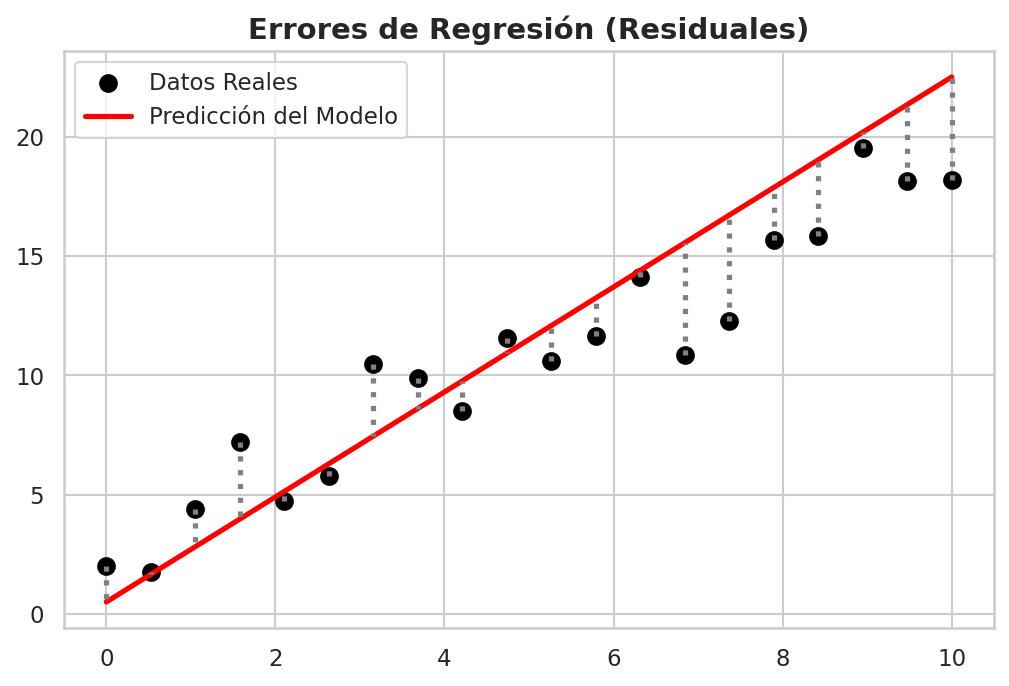

In [11]:
# Ejemplo visual de errores en regresión
np.random.seed(42)
X = np.linspace(0, 10, 20)
y_real = 2 * X + 1 + np.random.randn(20) * 2
y_pred = 2.2 * X + 0.5 # Modelo hipotético

plt.figure(figsize=(8, 5))
plt.scatter(X, y_real, color='black', label='Datos Reales')
plt.plot(X, y_pred, color='red', label='Predicción del Modelo')

# Dibujar las líneas de error (Residuals)
for i in range(len(X)):
    plt.plot([X[i], X[i]], [y_real[i], y_pred[i]], color='gray', linestyle='dotted')

plt.title('Errores de Regresión (Residuales)')
plt.legend()
plt.show()

## 2. Métricas de Clasificación



En clasificación, intentamos predecir una **categoría discreta** (ej. Spam/No Spam, Perro/Gato, ACV/No ACV, Llueve/No llueve, Manzana/Pera/Kiwi/Durazno -Sí, puede ser multiclase...).
A diferencia de la regresión, aquí el resultado es correcto o incorrecto (con ciertos matices).



### La Matriz de Confusión


Es la base para calcular las métricas de clasificación. Compara las predicciones con los valores reales.

*   **Verdaderos Positivos (TP):** El modelo predijo POSITIVO, y era POSITIVO.
*   **Verdaderos Negativos (TN):** El modelo predijo NEGATIVO, y era NEGATIVO.
*   **Falsos Positivos (FP - Error Tipo I):** El modelo predijo POSITIVO, pero era NEGATIVO (ej. Spam cuando era correo legítimo).
*   **Falsos Negativos (FN - Error Tipo II):** El modelo predijo NEGATIVO, pero era POSITIVO (ej. Paciente sano cuando en realidad tenía una enfermedad grave).

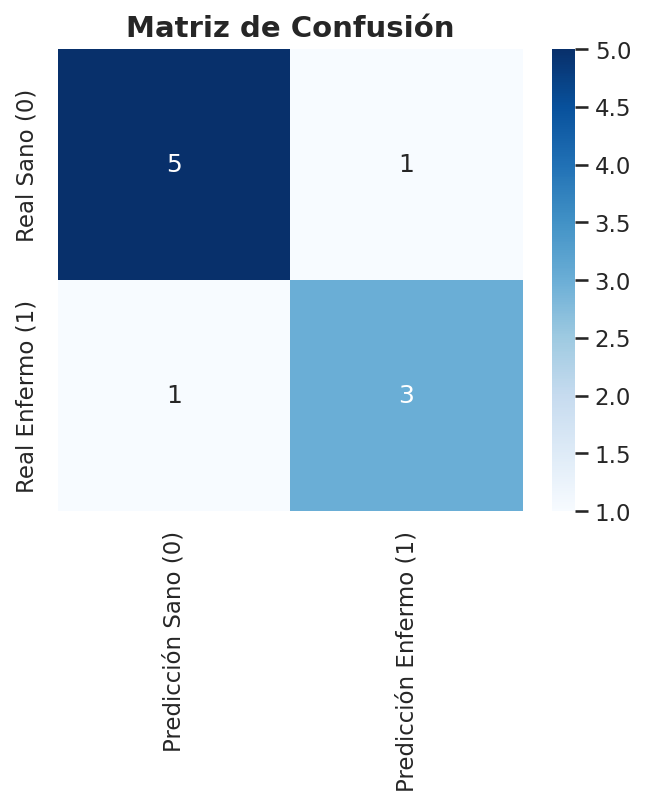

In [12]:
# Simulamos predicciones de clasificación (1 = Enfermo, 0 = Sano)
y_real_clf = [1, 0, 0, 1, 1, 0, 1, 0, 0, 0]
y_pred_clf = [1, 0, 0, 0, 1, 0, 1, 1, 0, 0]

cm = confusion_matrix(y_real_clf, y_pred_clf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g',
            xticklabels=['Predicción Sano (0)', 'Predicción Enfermo (1)'],
            yticklabels=['Real Sano (0)', 'Real Enfermo (1)'])
plt.title('Matriz de Confusión')
plt.show()

### Derivadas de la Matriz de Confusión



1.  **Exactitud (*Accuracy*):** Proporción de predicciones correctas sobre el total. $\frac{TP + TN}{Total}$. **¡Peligro!** En datasets muy desbalanceados (ej. 99% sanos, 1% enfermos), un modelo que siempre prediga "sano" tendrá 99% de Accuracy, pero será inútil.
2.  **Precisión (*Precision*):** De todos los que predijimos como POSITIVOS, ¿cuántos lo eran realmente? $\frac{TP}{TP + FP}$. Útil cuando el costo de un Falso Positivo es alto (ej. marcar correo legítimo como spam).
3.  **Sensibilidad / Exhaustividad (*Recall* / *Sensitivity*):** De todos los POSITIVOS reales, ¿cuántos logró encontrar el modelo? $\frac{TP}{TP + FN}$. Útil cuando el costo de un Falso Negativo es alto (ej. no detectar un cáncer).
4.  **F1-Score:** Media armónica entre *Precision* y *Recall*. Es una métrica excelente para datasets desbalanceados porque busca un equilibrio entre ambas métricas.

## Resultados y Discusión



La elección de la métrica depende enteramente del problema.
En un sistema de justicia penal (predecir si alguien es culpable), preferimos una alta **Precisión** (es peor condenar a un inocente: Falso Positivo).
En medicina diagnóstica, preferimos un alto **Recall** (es peor enviar a casa a un enfermo grave diciéndole que está sano: Falso Negativo).


## Conexiones y Próximos Pasos
- ➡️ **Siguiente:** Hemos cubierto los fundamentos teóricos. Es hora de adentrarnos en la práctica con el [Capítulo 2: Análisis Exploratorio de Datos](../02_eda/01_introduccion_eda.ipynb).



## Referencias
1. Documentación de [Scikit-Learn Metrics and Scoring](https://scikit-learn.org/stable/modules/model_evaluation.html).



---
## Entorno de Ejecución

In [13]:
from utils.environment import environment_table
environment_table()

Package,Version
Python,3.12.12
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
